In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import nltk

#Descargar stopwords en español
nltk.download('stopwords')
from nltk.corpus import stopwords

df = pd.read_csv('dataset_quejas_sugerencias_nube_de_palabras_tarea3p2.csv')
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ximena\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,ID,Comentario,Tipo
0,1,Deberían ofrecer más descuentos para clientes ...,Sugerencia
1,2,Podrían mejorar la experiencia en línea con un...,Sugerencia
2,3,La página web es muy lenta y difícil de usar.,Queja
3,4,No me gusta que el personal no esté bien capac...,Queja
4,5,Me gustaría que ofrecieran más promociones en ...,Sugerencia


In [2]:
# Separar el texto por tipo
quejas = df[df['Tipo'] == 'Queja']['Comentario']
sugerencias = df[df['Tipo'] == 'Sugerencia']['Comentario']

print("Total de Quejas:", len(quejas))
print("Total de Sugerencias:", len(sugerencias))


Total de Quejas: 4979
Total de Sugerencias: 5021


In [3]:
import re
from collections import Counter
stopwords_es = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = texto.lower()                          # minúsculas
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)  # eliminar signos y números
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stopwords_es]  # quitar stopwords
    return " ".join(palabras)

# aplicar limpieza solo a quejas
quejas_limpias = quejas.apply(limpiar_texto)

# Unir todas las quejas en un solo texto para la nube
texto_quejas = " ".join(quejas_limpias)


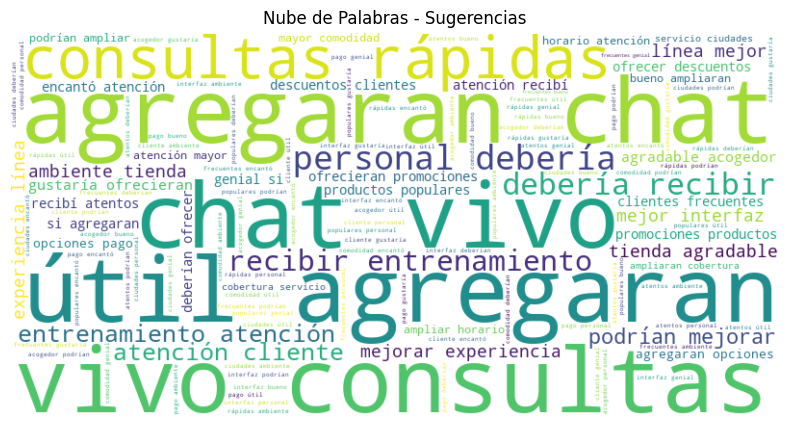

[('atención', 1505),
 ('agregaran', 1032),
 ('podrían', 997),
 ('útil', 569),
 ('chat', 569),
 ('vivo', 569),
 ('consultas', 569),
 ('rápidas', 569),
 ('personal', 549),
 ('debería', 549)]

In [4]:
sugerencias_limpias = sugerencias.apply(limpiar_texto)

texto_sugerencias = " ".join(sugerencias_limpias)

# Generar nube
wordcloud_sugerencias = WordCloud(width=800, height=400, background_color='white',
                                  stopwords=stopwords_es).generate(texto_sugerencias)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_sugerencias, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de Palabras - Sugerencias")
plt.show()

# Palabras más comunes
frecuencias_sugerencias = Counter(texto_sugerencias.split()).most_common(10)
frecuencias_sugerencias


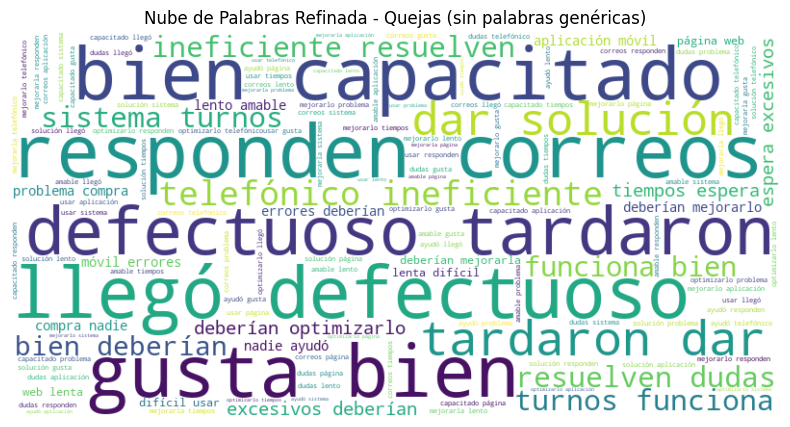

In [5]:
#ampliación de stopwords con palabras genéricas
palabras_genericas = {"cliente", "clientes", "empresa", "producto", "productos",
                      "servicio", "servicios", "personal", "gente", "atención"}

stopwords_custom = stopwords_es.union(palabras_genericas)

def limpiar_texto_custom(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stopwords_custom]
    return " ".join(palabras)

quejas_limpias_custom = quejas.apply(limpiar_texto_custom)
texto_quejas_custom = " ".join(quejas_limpias_custom)

#Nueva nube de palabras
wordcloud_quejas_custom = WordCloud(width=800, height=400, background_color='white').generate(texto_quejas_custom)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_quejas_custom, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de Palabras Refinada - Quejas (sin palabras genéricas)")
plt.show()


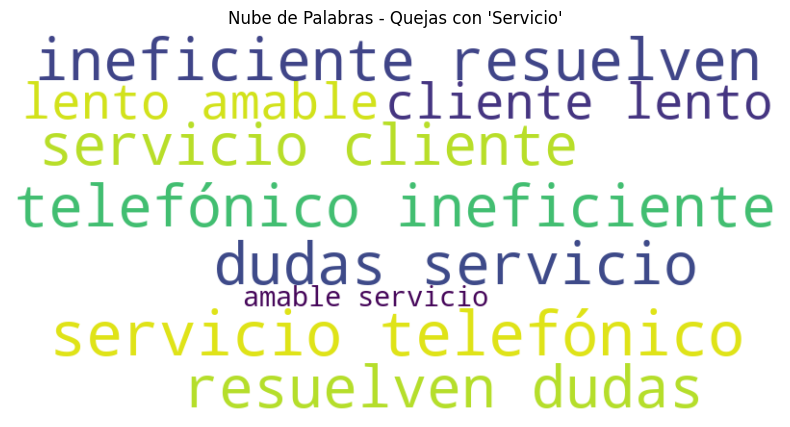

[('servicio', 987),
 ('telefónico', 502),
 ('ineficiente', 502),
 ('resuelven', 502),
 ('dudas', 502),
 ('cliente', 485),
 ('lento', 485),
 ('amable', 485)]

In [6]:
# Filtrar quejas que mencionen la palabra servicio
quejas_servicio = quejas[quejas.str.contains("servicio", case=False, na=False)]

quejas_servicio_limpias = quejas_servicio.apply(limpiar_texto)

texto_servicio = " ".join(quejas_servicio_limpias)

# Nube para servicio
wordcloud_servicio = WordCloud(width=800, height=400, background_color='white',
                               stopwords=stopwords_es).generate(texto_servicio)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_servicio, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de Palabras - Quejas con 'Servicio'")
plt.show()

frecuencia_servicio = Counter(texto_servicio.split()).most_common(10)
frecuencia_servicio
